In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Matplotlib is the core plotting library
# Seaborn is built on top of matplotlib and provides
# better defaults and easier statistical plots
plt.style.use("seaborn-v0_8")

In [ ]:
PROJECT_ROOT = Path().resolve().parent #the .resolve() method belongs to the pathlib.Path objects. It is used to make a path absolute, resolve any symbolic links, and eliminate "." (current directory) and ".." (parent directory) components to return the canonical path to a file system item. 
weather_path = PROJECT_ROOT / "data" / "raw" / "weather" #Get global path of all weather cities

dfs = [] # to store all df containing each city's data
for city_path in weather_path.glob("*_weather.csv"):  #glob method allows you to find pathnames matching a specified pattern
    city = city_path.stem.replace("_weather", "") # stem as the names suggest the get the stem (file name) from the relative or absolute path
    df = pd.read_csv(city_path)
    df["city"] = city
    dfs.append(df)

weather_data = pd.concat(dfs, ignore_index=True) #ignore index tells to use default indexing
weather_data["date"] = pd.to_datetime(weather_data["date"])
weather_data.head()


65730

In [13]:
weather_data.size

65730

In [4]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10955 entries, 0 to 10954
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         10955 non-null  datetime64[ns]
 1   temperature  10955 non-null  float64       
 2   wind_speed   10748 non-null  float64       
 3   rainfall     7196 non-null   float64       
 4   pressure     9840 non-null   float64       
 5   city         10955 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 513.6+ KB


In [5]:
weather_data.describe()

,date,temperature,wind_speed,rainfall,pressure
count,10955,10955.000000,10748.000000,7196.000000,9840.000000
mean,2020-12-31 00:00:00,26.287467,8.340631,6.364216,1009.269604
min,2018-01-01 00:00:00,6.900000,0.300000,0.000000,989.600000
25%,2019-07-02 00:00:00,23.600000,5.300000,0.000000,1005.700000
50%,2020-12-31 00:00:00,26.900000,7.900000,0.000000,1009.900000
75%,2022-07-02 00:00:00,29.500000,10.500000,3.925000,1013.400000
max,2023-12-31 00:00:00,39.200000,30.400000,374.900000,1024.500000
std,NaN,4.580960,4.214290,19.103678,5.368115


In [ ]:
#Percentage of missing rows 
weather_data.isna().mean() * 100

date            0.000000
temperature     0.000000
wind_speed      1.889548
rainfall       34.313099
pressure       10.178001
city            0.000000
dtype: float64

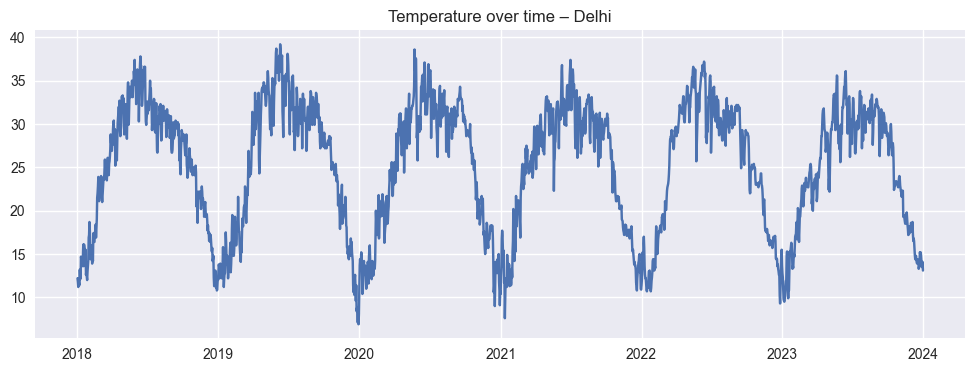

In [11]:
city = "delhi"
#we create a specific city df by using condition on weather_data
city_df = weather_data[weather_data["city"]==city]
#plot the date vs temp
plt.figure(figsize=(12,4))
plt.plot(city_df["date"], city_df["temperature"])
plt.title(f"Temperature over time – {city.title()}")
plt.show()

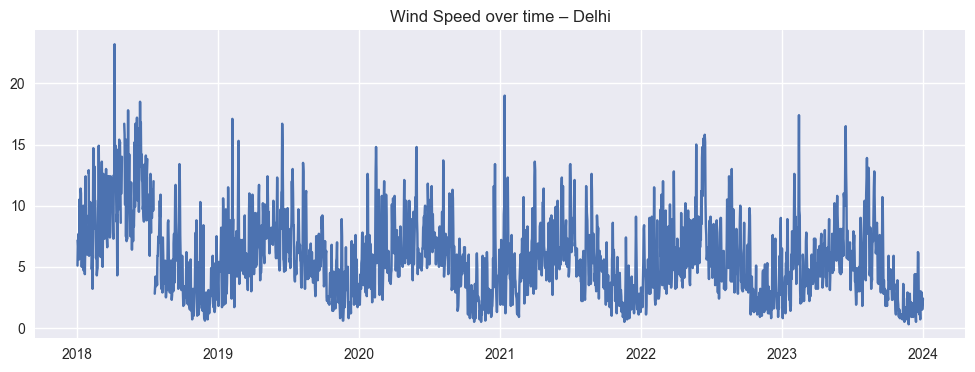

In [15]:
plt.figure(figsize=(12,4))
plt.plot(city_df["date"], city_df["wind_speed"])
plt.title(f"Wind Speed over time – {city.title()}")
plt.show()

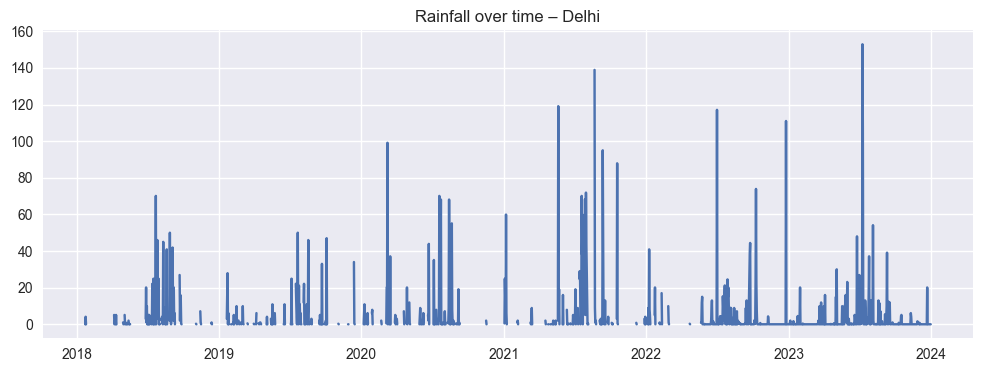

In [16]:
plt.figure(figsize=(12,4))
plt.plot(city_df["date"], city_df["rainfall"])
plt.title(f"Rainfall over time – {city.title()}")
plt.show()

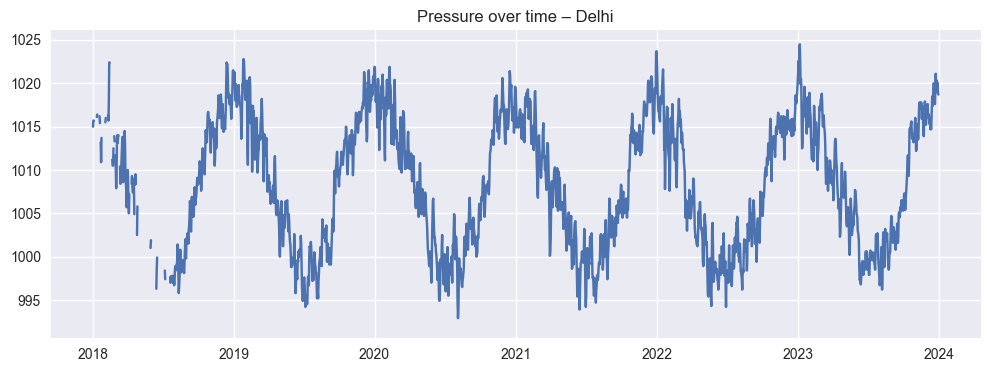

In [17]:
plt.figure(figsize=(12,4))
plt.plot(city_df["date"], city_df["pressure"])
plt.title(f"Pressure over time – {city.title()}")
plt.show()